# <div dir='rtl'>تمرین پنجم درس یادگیری عمیق سینا ملاابراهیمی</div>

# <div dir='rtl'>کتابخانه لازم </div>

# <div dir='rtl'>بخش اول</div>

# <div dir='rtl'>شمارش تصاویر دیتاست</div>

In [1]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image
import random
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.manifold import TSNE
import pretty_midi
import numpy as np

In [2]:
path = Path("50k")

all_images = list(path.rglob("*.jpg"))

num_images = len(all_images)


print(f"Number of jpg files: {num_images}")

# --- HOMELANDER: DON'T TOUCH IT!!
test_dataset_count = num_images

Number of jpg files: 50000


# <div dir='rtl'>نمایش نمونه هایی از تصاویر دیتاست</div>

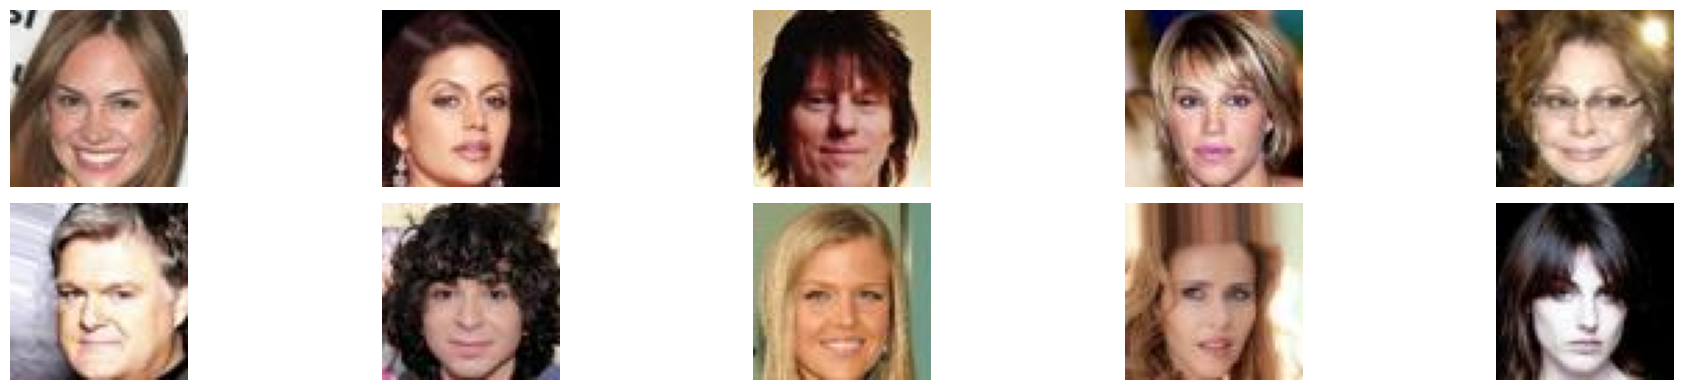

In [3]:
sample_images = random.sample(all_images, 10)
plt.figure(figsize=(20, 4))
for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()

# <div dir='rtl'>تنظیم seed  و دستگاه اجرا</div>

In [4]:
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
print("Seed fixed.")
print("Using device:", device)

Seed fixed.
Using device: cuda


# <div dir='rtl'> تقسیم‌بندی مجموعه‌داده (Train, Validation, Test Split)</div>

In [5]:
SEED = 42
train_paths, temp_paths = train_test_split(all_images, test_size=0.2, random_state=SEED)
val_paths, test_paths = train_test_split(temp_paths, test_size=0.5, random_state=SEED)
if train_paths is not None:
    print("Train:", len(train_paths))
    print("Val:", len(val_paths))
    print("Test:", len(test_paths))
# --- HOMELANDER: DON'T TOUCH IT!!
if train_paths:
    test_train_count = len(train_paths)
    test_val_count = len(val_paths)
    test_test_count = len(test_paths)
    test_split_seed = SEED

Train: 40000
Val: 5000
Test: 5000


# <div dir='rtl'>پیش پردازش و تبدیل تصاویر</div>

In [6]:
Image_size = 64 
train_transform = transforms.Compose([transforms.Resize((Image_size, Image_size)),
                                       transforms.RandomHorizontalFlip(p=0.5),
                                       transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((Image_size, Image_size)),
                                     transforms.ToTensor()])
# --- HOMELANDER: DON'T TOUCH IT!!
if Image_size:
    test_image_size = Image_size
    test_train_transform_names = [type(t).__name__ for t in train_transform.transforms]
    test_test_transform_names = [type(t).__name__ for t in test_transform.transforms]
    test_train_flip_p = train_transform.transforms[1].p

# <div dir='rtl'>ساخت کلاس celebA dataset</div>

In [7]:
class CelebADataset(Dataset):
    def __init__(self, image_paths, transform=None):
        """
        Args:
            image_paths: list of image file paths
            transform: torchvision transforms applied to each image
        """
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        """
        Return the number of images in the dataset.
        """
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Load one image, convert it to RGB, apply transform if available,
        and return the image.
        """
        path = self.image_paths[idx]

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

# <div dir='rtl'> ساخت Dataset برای داده‌های آموزش، اعتبارسنجی و آزمون</div>

In [8]:
train_dataset = CelebADataset(train_paths, train_transform)
val_dataset = CelebADataset(val_paths, test_transform)
test_dataset = CelebADataset(test_paths, test_transform)
# --- HOMELANDER: HEY JUST TO BE CLEAR, DON'T EVER NEVER LOOK AT THIS OKAY?? YEAH ADABODY   
test_dataset_class_train_len = len(train_dataset)
test_dataset_class_val_len = len(val_dataset)
test_dataset_class_test_len = len(test_dataset)

# <div dir='rtl'> ایجاد DataLoader برای مدیریت دسته‌ای داده‌ها (Batching)</div>

In [9]:
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size= BATCH_SIZE)
test_loader = DataLoader(test_dataset,batch_size= BATCH_SIZE)
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader) if train_loader is not None else 0}")
print(f"Val batches: {len(val_loader) if val_loader is not None else 0}")
print(f"Test batches: {len(test_loader) if test_loader is not None else 0}")
# --- HOMELANDER: OH BOY YOU CAN'T ESCAPE FROM DESTENY... I FNISH YOU SOON. PROMISE 
if BATCH_SIZE:
    test_train_loader_shuffle = train_loader.dataset is not None and train_loader.batch_size == BATCH_SIZE
    test_train_batches_count = len(train_loader)
    test_val_batches_count = len(val_loader)
    test_test_batches_count = len(test_loader)

Batch size: 64
Train batches: 625
Val batches: 79
Test batches: 79


# <div dir='rtl'> مشاهده یک batch از تصاویر آموزشی</div>

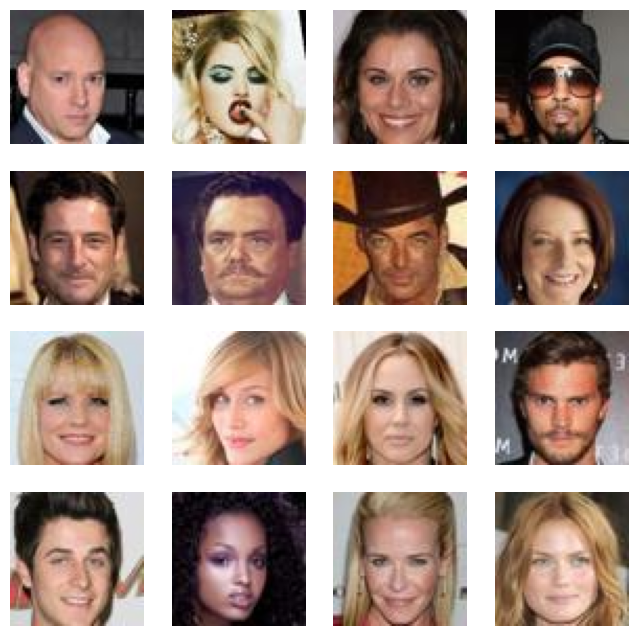

In [10]:
images = next(iter(train_loader))
fig , axes = plt.subplots(4,4,figsize = (8,8))
for i, ax in enumerate(axes.flatten()):
    img = images[i]
    img_permuted = img.permute(1, 2, 0)
    ax.imshow(img_permuted)
    ax.axis("off")

# --- HOMELANDER: WE BOTH HATE THIS UNIVERSITY, ESPECIALY THE NEWCOMERS. RIGHT?!! RIGHT?!!
test_batch_images_shape = list(images.shape) if images is not None else None

# <div dir = 'rtl'> بررسی آماری داده‌ها (Data Statistics)</div>

In [11]:
batch = next(iter(train_loader))

batch_shape = batch.shape
batch_min = batch.min().item()
batch_max = batch.max().item()
batch_mean = batch.mean().item()
batch_std = batch.std().item()

print(f"Shape: {batch_shape}")
print(f"Min: {batch_min:.4f}")
print(f"Max: {batch_max:.4f}")
print(f"Mean: {batch_mean:.4f}")
print(f"Std: {batch_std:.4f}")

# --- HOMELANDER: BUTCHER!! YOU AGAIN. YOU CAN TOUCH IT BUT FIRST, SAY HELLO TO MY LITTLE FRIEND HAHAHA...
test_stats_shape = list(batch_shape) if batch_shape is not None else []
test_stats_min = float(batch_min) if batch_min is not None else -1.0
test_stats_max = float(batch_max) if batch_max is not None else -1.0

Shape: torch.Size([64, 3, 64, 64])
Min: 0.0000
Max: 1.0000
Mean: 0.4461
Std: 0.2809


# <dov dir = 'rtl'>محاسبه میانگین و انحراف معیار کل دیتاست</div>

In [12]:
mean = torch.zeros(3)
std = torch.zeros(3)
n_samples = 0

for images in tqdm(train_loader):

    batch_size = images.size(0)

    images_flattened = images.view(batch_size, 3, -1)

    mean += images_flattened.mean(dim=2).sum(dim=0)
    std += images_flattened.std(dim=2).sum(dim=0)

    n_samples += batch_size

mean /= n_samples
std /= n_samples
print(f"Global Mean: {mean}")
print(f"Global Std: {std}")

# --- HOMELANDER: HEY JUST TO BE CLEAR, DON'T EVER NEVER LOOK AT THIS OKAY?? ADABODY
test_global_mean = mean.tolist() if mean is not None else []
test_global_std = std.tolist() if std is not None else []
test_n_samples = n_samples

100%|██████████| 625/625 [02:04<00:00,  5.00it/s]

Global Mean: tensor([0.5164, 0.4152, 0.3623])
Global Std: tensor([0.2597, 0.2320, 0.2242])


In [13]:
torch.save(
    {
        "train": [str(p) for p in train_paths],
        "val": [str(p) for p in val_paths],
        "test": [str(p) for p in test_paths],
    },
    "celeba_splits.pt"
)

print("Splits saved.")

Splits saved.


# <div dir ='rtl'> پیاده‌سازی Convolutional Autoencoder</div>

In [14]:
class ConvAE(nn.Module):
    def __init__(self, latent_dim = 128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32,64,kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64,128,kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(128,256,kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.fc_enc = nn.Linear(256*4*4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim,256*4*4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128,kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128,64,kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64,32,kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,3,kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0),-1)
        z = self.fc_enc(x)
        return z 
    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(-1,256,4,4)
        x = self.decoder(x)
        return x
    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

In [15]:
latent_dim = 128
model = ConvAE(latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

# <div dir='rtl'> بررسی ساختار و تعداد پارامترهای مدل</div>

In [16]:
total_params = sum(p.numel() for p in model.parameters())

print(model)
print("\n" + "="*30)
print(f"Total Parameters: {total_params:,}")
print("="*30)


# --- HOMELANDER: DON'T TOUCH IT!!
test_total_params = total_params
test_ae = model

ConvAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
  )
  (fc_enc): Linear(in_features=4096, out_features=128, bias=True)
  (fc_dec): Linear(in_features=128, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 12

# <div dir='rtl'>تست ابعاد</div>

In [17]:
images = next(iter(train_loader)).to(device)
model.eval()
with torch.no_grad():
    outputs = model(images)
print(f"Input batch shape:  {images.shape}")
print(f"Output batch shape: {outputs.shape}")

Input batch shape:  torch.Size([64, 3, 64, 64])
Output batch shape: torch.Size([64, 3, 64, 64])


# <div dir='rtl'> یک گام آموزش (One Training Step)</div>

In [18]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
images = next(iter(train_loader)).to(device)
model.train()
outputs = model(images)
loss = criterion(outputs, images)
optimizer.zero_grad()
loss.backward()
optimizer.step()
train_step_loss = loss.item()
print("Loss:", train_step_loss)
# --- HOMELANDER: DON'T TOUCH IT!!
test_ae_one_step_loss = round(train_step_loss, 6)

Loss: 0.10275214910507202


# <div dir='rtl'> پیاده‌سازی حلقه آموزش (Training Loop)</div>

In [19]:
def train_epoch(model, loader, optimizer, criterion, device):
    """
    Trains the model for one epoch.
    """
    model.train()
    running_loss = 0.0 
    for images in tqdm (loader, desc='training', leave= False):
        images = images.to(device)
        outputs = model(images)
        optimizer.zero_grad()
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        running_loss = running_loss + loss.item()
    average_loss = running_loss / len(loader)
    return average_loss

print("Loss:", train_step_loss)

# --- HOMELANDER: DON'T TOUCH IT!!
test_ae_one_step_loss = round(train_step_loss, 6)

Loss: 0.10275214910507202


# <div dir='rtl'>پیاده‌سازی تابع ارزیابی مدل</div>

In [20]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluates the model on a validation or test DataLoader.

    Arguments:
    model -- the PyTorch model to be evaluated
    loader -- DataLoader for validation or test data
    criterion -- loss function
    device -- device to run evaluation on

    Returns:
    average_loss -- float, average reconstruction loss
    """
    model.eval()
    running_loss = 0.0 
    for images in loader :
        images = images.to(device)
        outputs = model(images)
        loss = criterion(outputs, images)
        running_loss = running_loss + loss.item()
    average_loss = running_loss / len(loader)
    return average_loss

# <div dir='rtl'>اجرای حلقه کامل آموزش</div>

In [21]:
EPOCHS = 15 
train_losses = []
val_losses = []
best_val = float("inf")
for epoch in range(EPOCHS) :
    train_loss = train_epoch(model, train_loader, optimizer = optimizer, criterion = criterion,device = device)
    val_loss = evaluate(model, val_loader, criterion= criterion, device = device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train: {train_loss:.5f} | "
        f"Val: {val_loss:.5f}"
    )
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(),"best_ae.pth")
        print("Saved best model.")


Epoch 1/15 | Train: 0.01717 | Val: 0.01003
Saved best model.


Epoch 2/15 | Train: 0.00881 | Val: 0.00759
Saved best model.


Epoch 3/15 | Train: 0.00731 | Val: 0.00660
Saved best model.


Epoch 4/15 | Train: 0.00655 | Val: 0.00621
Saved best model.


Epoch 5/15 | Train: 0.00608 | Val: 0.00635


...

Epoch 11/15 | Train: 0.00516 | Val: 0.00500
Saved best model.


Epoch 12/15 | Train: 0.00507 | Val: 0.00514


Epoch 13/15 | Train: 0.00501 | Val: 0.00491
Saved best model.


Epoch 14/15 | Train: 0.00497 | Val: 0.00497


Epoch 15/15 | Train: 0.00491 | Val: 0.00504


# <div dir='rtl'>رسم نمودار loss</div>

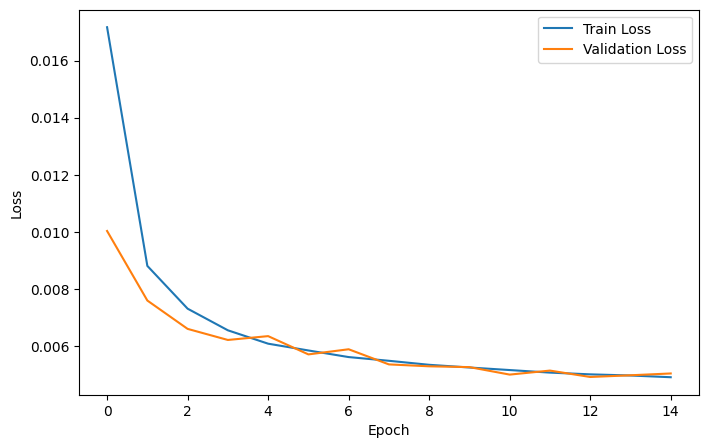

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()


# --- HOMELANDER: DON'T TOUCH IT!!
test_plot_train_losses_length = len(train_losses)
test_plot_val_losses_length = len(val_losses)
test_plot_train_loss_first = round(float(train_losses[0]), 6)
test_plot_train_loss_last = round(float(train_losses[-1]), 6)
test_plot_val_loss_first = round(float(val_losses[0]), 6)
test_plot_val_loss_last = round(float(val_losses[-1]), 6)

# <div dir='rtl'> مشاهده تصاویر بازسازی‌شده</div>

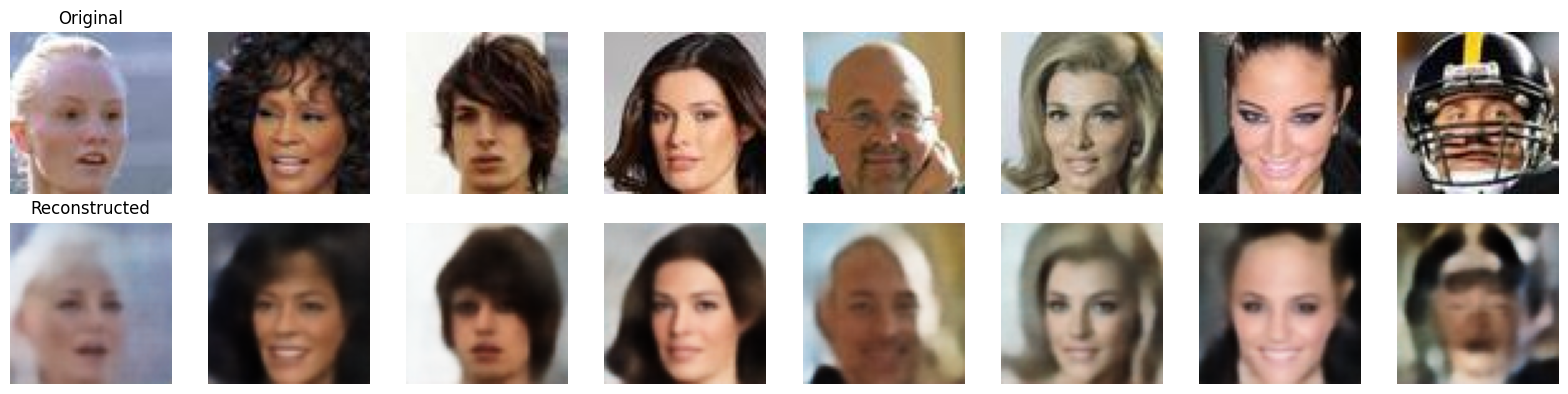

In [23]:
images = next(iter(test_loader)).to(device)

with torch.no_grad():
    recon = model(images)

images = images.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):

    axes[0, i].imshow(images[i].permute(1, 2, 0))
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i].permute(1, 2, 0))
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")

plt.tight_layout()
plt.show()
# --- HOMELANDER: DON'T TOUCH IT!!
recon_vis_num_images = 8
recon_vis_input_shape = list(images.shape)
recon_vis_output_shape = list(recon.shape)

recon_vis_input_min = round(float(images.min().item()), 6)
recon_vis_input_max = round(float(images.max().item()), 6)

recon_vis_output_min = round(float(recon.min().item()), 6)
recon_vis_output_max = round(float(recon.max().item()), 6)

In [24]:
submission = {}

# Dataset
submission["test_dataset_count"] = test_dataset_count

submission["test_train_count"] = test_train_count
submission["test_val_count"] = test_val_count
submission["test_test_count"] = test_test_count
submission["test_split_seed"] = test_split_seed


submission["test_image_size"] = test_image_size
submission["test_train_transform_names"] = test_train_transform_names
submission["test_test_transform_names"] = test_test_transform_names
submission["test_train_flip_p"] = test_train_flip_p


submission["test_dataset_class_train_len"] = test_dataset_class_train_len
submission["test_dataset_class_val_len"] = test_dataset_class_val_len
submission["test_dataset_class_test_len"] = test_dataset_class_test_len


submission["test_train_loader_shuffle"] = test_train_loader_shuffle
submission["test_train_batches_count"] = test_train_batches_count
submission["test_val_batches_count"] = test_val_batches_count
submission["test_test_batches_count"] = test_test_batches_count

submission["test_batch_images_shape"] = test_batch_images_shape

submission["test_stats_shape"] = test_stats_shape
submission["test_stats_min"] = test_stats_min
submission["test_stats_max"] = test_stats_max

submission["test_global_mean"] = test_global_mean
submission["test_global_std"] = test_global_std
submission["test_n_samples"] = test_n_samples

# Model
submission["test_total_params"] = test_total_params
submission["ae_num_encoder_layers"] = len(model.encoder)
submission["ae_num_decoder_layers"] = len(model.decoder)

submission["ae_encoder_layer_types"] = [
    type(layer).__name__ for layer in model.encoder
]

submission["ae_decoder_layer_types"] = [
    type(layer).__name__ for layer in model.decoder
]


submission["test_plot_train_losses_length"] = test_plot_train_losses_length
submission["test_plot_val_losses_length"] = test_plot_val_losses_length
submission["test_plot_train_loss_first"] = test_plot_train_loss_first
submission["test_plot_train_loss_last"] = test_plot_train_loss_last
submission["test_plot_val_loss_first"] = test_plot_val_loss_first
submission["test_plot_val_loss_last"] = test_plot_val_loss_last



In [25]:
import json
with open('data.json', 'w', encoding='utf-8') as f:
    json.dump(submission, f, ensure_ascii=False, indent=4)

In [26]:
class ConvVAE(nn.Module):
    
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,32,4,2,1),
            nn.InstanceNorm2d(32),
            nn.ReLU(True),
            nn.Conv2d(32,64,4,2,1),
            nn.InstanceNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64,128,4,2,1),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.Conv2d(128,256,4,2,1),
            nn.ReLU(True))
        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim,256*4*4)
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.InstanceNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.InstanceNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32,3,4,2,1),
            nn.Sigmoid())
    def encode (self, x):
        x = self.encoder(x)
        x = x.view(x.size(0),-1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    def reparameterize(self, mu, logvar): 
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(-1,256,4,4)
        x = self.decoder(x)
        return x
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [27]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(
        recon,
        x,
        reduction="sum"
    ) / x.size(0)

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp(),
        dim=1
    ).mean()

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss

In [28]:
def beta_scheduler(epoch, total_epochs):
    
    warmup = 4

    if epoch < warmup:
        return 0.0

    beta = (epoch - warmup) / (total_epochs - warmup)

    return min(beta, 1.0)

In [29]:
latent_dim = 128
vae = ConvVAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

In [30]:
def train_epoch_vae(model, loader, optimizer,device,epoch,total_epochs):
    model.train()
    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    beta = beta_scheduler(epoch, total_epochs)
    for images in tqdm(loader, leave=False):
        images = images.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(images)
        loss, recon_loss, kl_loss = vae_loss(recon,images,mu,logvar,beta)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_loss.item()
    return (running_loss / len(loader),
        running_recon / len(loader),
        running_kl / len(loader))

In [31]:
@torch.no_grad()
def evaluate_vae(model,loader,device,epoch,total_epochs):
    model.eval()
    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    beta = beta_scheduler(epoch, total_epochs)
    for images in loader:
        images = images.to(device)
        recon, mu, logvar = model(images)
        loss, recon_loss, kl_loss = vae_loss(recon,images, mu, logvar, beta)
        running_loss += loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_loss.item()
    return (running_loss / len(loader),
        running_recon / len(loader),
        running_kl / len(loader))

In [32]:
EPOCHS = 15

train_losses = []
val_losses = []
best_val = float("inf")
for epoch in range(EPOCHS):
    train_loss, train_rec, train_kl = train_epoch_vae(vae,train_loader,optimizer,device,epoch,EPOCHS)
    val_loss, val_rec, val_kl = evaluate_vae(vae,val_loader,device,epoch,EPOCHS)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | β={beta_scheduler(epoch,EPOCHS):.2f}"
        f" | Train={train_loss:.4f}"
        f" | Val={val_loss:.4f}"
        f" | Train Recon={train_rec:.4f}"
        f" | Val Recon={val_rec:.4f}"
        f" | Train KL={train_kl:.4f}"
        f" | Val KL={val_kl:.4f}"
    )

    beta = beta_scheduler(epoch, EPOCHS)
    if beta >= 0.8:
        if val_loss < best_val:
            best_val = val_loss
            torch.save(vae.state_dict(), "best_vae.pth")
            print("Best model saved.")

Epoch 1/15 | β=0.00 | Train=287.8308 | Val=173.4737 | Train Recon=287.8308 | Val Recon=173.4737 | Train KL=7724.5918 | Val KL=7124.7670


Epoch 2/15 | β=0.00 | Train=151.7430 | Val=131.6692 | Train Recon=151.7430 | Val Recon=131.6692 | Train KL=7785.2373 | Val KL=8822.5639


Epoch 3/15 | β=0.00 | Train=123.8828 | Val=113.4453 | Train Recon=123.8828 | Val Recon=113.4453 | Train KL=9234.0941 | Val KL=10784.8907


Epoch 4/15 | β=0.00 | Train=109.7888 | Val=105.3981 | Train Recon=109.7888 | Val Recon=105.3981 | Train KL=11349.2352 | Val KL=13008.7930


Epoch 5/15 | β=0.00 | Train=101.9828 | Val=99.2075 | Train Recon=101.9828 | Val Recon=99.2075 | Train KL=12985.8312 | Val KL=14064.7728


...

Epoch 11/15 | β=0.55 | Train=184.6553 | Val=185.1704 | Train Recon=128.8307 | Val Recon=129.3064 | Train KL=102.3452 | Val KL=102.4174


Epoch 12/15 | β=0.64 | Train=189.4585 | Val=195.2960 | Train Recon=131.5040 | Val Recon=139.2909 | Train KL=91.0713 | Val KL=88.0080


Epoch 13/15 | β=0.73 | Train=194.6002 | Val=196.5694 | Train Recon=134.8052 | Val Recon=139.4686 | Train KL=82.2182 | Val KL=78.5136


Epoch 14/15 | β=0.82 | Train=199.0506 | Val=198.7222 | Train Recon=137.5338 | Val Recon=135.8326 | Train KL=75.1871 | Val KL=76.8650
Best model saved.


Epoch 15/15 | β=0.91 | Train=202.9470 | Val=207.9210 | Train Recon=139.8422 | Val Recon=145.7342 | Train KL=69.4153 | Val KL=68.4055


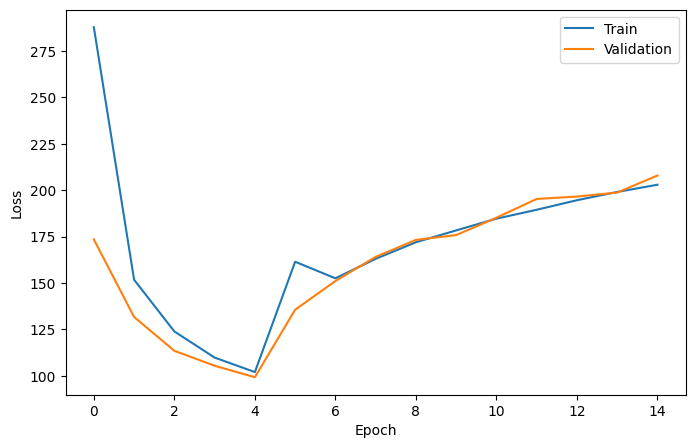

In [33]:
plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Best model loaded.


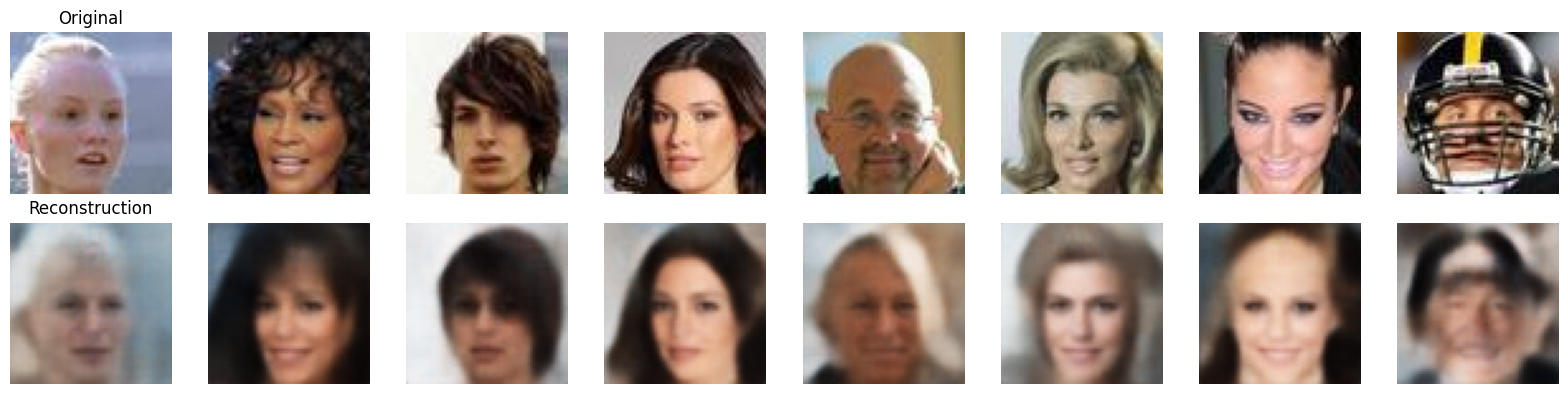

In [34]:
vae.load_state_dict(
    torch.load(
        "best_vae.pth",
        map_location=device
    )
)

vae.eval()

print("Best model loaded.")
images = next(iter(test_loader)).to(device)

with torch.no_grad():

    recon, _, _ = vae(images)

images = images.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2,8,figsize=(16,4))

for i in range(8):

    axes[0,i].imshow(
        images[i].permute(1,2,0)
    )
    axes[0,i].axis("off")

    axes[1,i].imshow(
        recon[i].permute(1,2,0)
    )
    axes[1,i].axis("off")

axes[0,0].set_title("Original")
axes[1,0].set_title("Reconstruction")

plt.tight_layout()
plt.show()

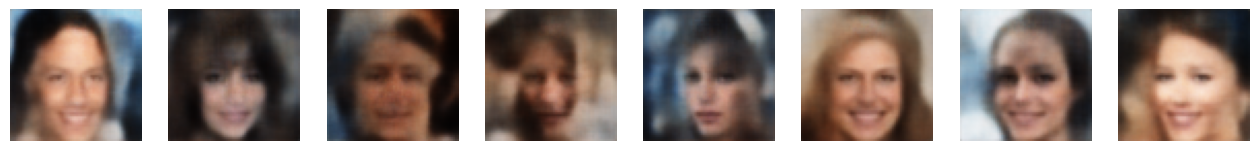

In [35]:
num_images = 8

z = torch.randn(
    num_images,
    latent_dim,
    device=device
)

with torch.no_grad():

    fake = vae.decode(z)

fake = fake.cpu()

fig, axes = plt.subplots(1,8,figsize=(16,2))

for i in range(num_images):

    axes[i].imshow(
        fake[i].permute(1,2,0)
    )

    axes[i].axis("off")

plt.show()

In [36]:
images = next(iter(test_loader)).to(device)

img1 = images[0].unsqueeze(0)

img2 = images[1].unsqueeze(0)

with torch.no_grad():

    mu1, log1 = vae.encode(img1)
    mu2, log2 = vae.encode(img2)

    z1 = vae.reparameterize(mu1,log1)
    z2 = vae.reparameterize(mu2,log2)

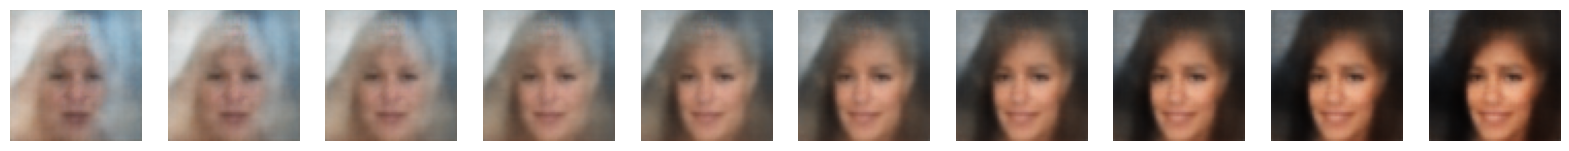

In [37]:
steps = 10

alphas = torch.linspace(
    0,
    1,
    steps
)

fig, axes = plt.subplots(
    1,
    steps,
    figsize=(20,2)
)

with torch.no_grad():

    for i, alpha in enumerate(alphas):

        z = (1-alpha)*z1 + alpha*z2

        img = vae.decode(z)

        axes[i].imshow(
            img.squeeze().cpu().permute(1,2,0)
        )

        axes[i].axis("off")

plt.show()

In [38]:
def slerp(z1, z2, alpha):

    z1_norm = z1 / torch.norm(z1, dim=1, keepdim=True)
    z2_norm = z2 / torch.norm(z2, dim=1, keepdim=True)

    dot = (z1_norm * z2_norm).sum(dim=1, keepdim=True)

    dot = torch.clamp(dot, -0.9995, 0.9995)

    omega = torch.acos(dot)

    sin_omega = torch.sin(omega)

    z = (
        torch.sin((1 - alpha) * omega) / sin_omega * z1
        +
        torch.sin(alpha * omega) / sin_omega * z2
    )

    return z

In [39]:
images = next(iter(test_loader)).to(device)

img1 = images[0].unsqueeze(0)
img2 = images[1].unsqueeze(0)

vae.eval()

with torch.no_grad():

    mu1, logvar1 = vae.encode(img1)
    mu2, logvar2 = vae.encode(img2)

    z1 = vae.reparameterize(mu1, logvar1)
    z2 = vae.reparameterize(mu2, logvar2)

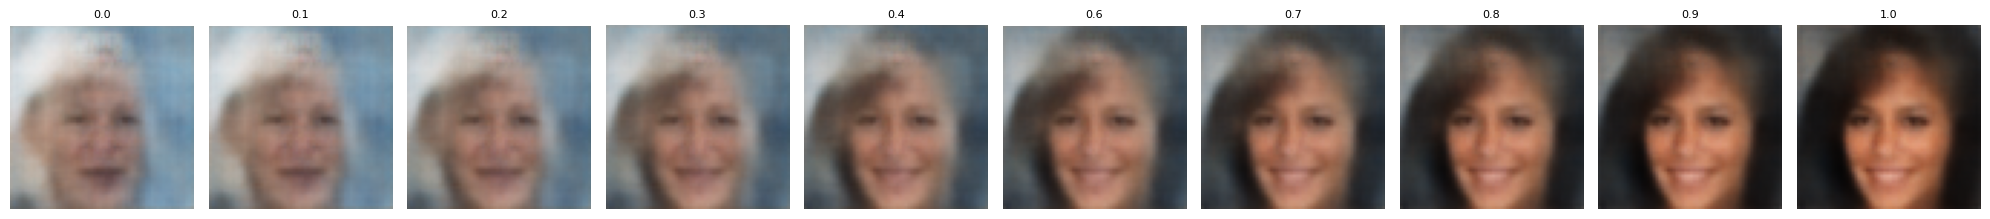

In [40]:
steps = 10

alphas = torch.linspace(0,1,steps)

fig, axes = plt.subplots(
    1,
    steps,
    figsize=(20,3)
)

with torch.no_grad():

    for i, alpha in enumerate(alphas):

        z = slerp(
            z1,
            z2,
            alpha
        )

        img = vae.decode(z)

        axes[i].imshow(
            img.squeeze().cpu().permute(1,2,0)
        )

        axes[i].axis("off")

        axes[i].set_title(
            f"{alpha:.1f}",
            fontsize=8
        )

plt.tight_layout()

plt.show()

In [41]:

features = []

vae.eval()

with torch.no_grad():

    for images in test_loader:

        images = images.to(device)

        mu, _ = vae.encode(images)

        features.append(
            mu.cpu()
        )

        if len(torch.cat(features)) >= 500:
            break

features = torch.cat(features)[:500]

In [42]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

embedding = tsne.fit_transform(
    features.numpy()
)

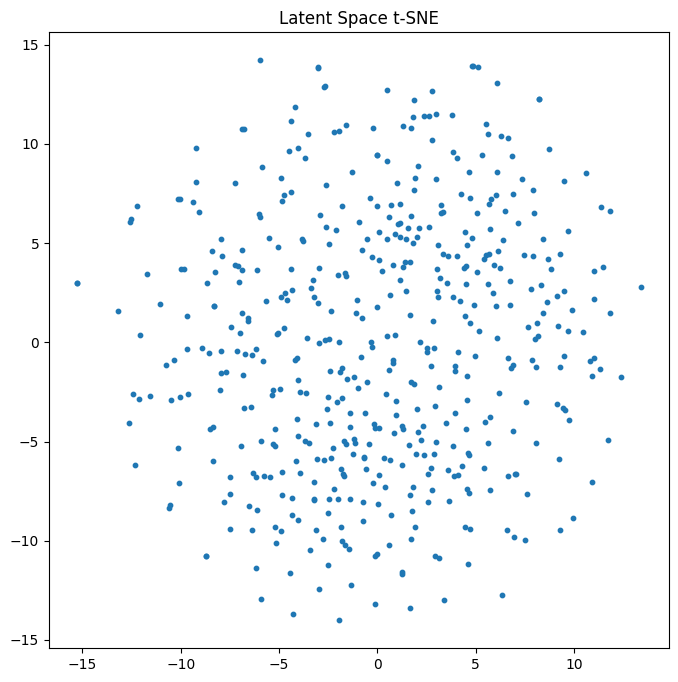

In [43]:
plt.figure(figsize=(8,8))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10
)

plt.title("Latent Space t-SNE")

plt.show()

In [44]:
root = Path("classical-music")
midi_files = list(root.rglob("*.mid"))
print("Number of MIDI files:", len(midi_files))
print(midi_files[:5])

Number of MIDI files: 295
[WindowsPath('classical-music/albeniz/alb_esp1.mid'), WindowsPath('classical-music/albeniz/alb_esp2.mid'), WindowsPath('classical-music/albeniz/alb_esp3.mid'), WindowsPath('classical-music/albeniz/alb_esp4.mid'), WindowsPath('classical-music/albeniz/alb_esp5.mid')]


In [45]:
def extract_notes(midi_path):
    
    midi = pretty_midi.PrettyMIDI(str(midi_path))

    notes = []

    for instrument in midi.instruments:

        if instrument.is_drum:
            continue

        for note in instrument.notes:

            notes.append(note.pitch)

    return notes

In [46]:
notes = extract_notes(midi_files[0])

print(notes[:50])

print("Number of notes:", len(notes))

[81, 88, 86, 88, 86, 84, 86, 88, 89, 91, 88, 89, 88, 86, 88, 86, 84, 82, 57, 61, 64, 69, 73, 76, 69, 73, 76, 81, 85, 88, 85, 81, 76, 73, 69, 76, 73, 69, 64, 61, 57, 81, 88, 86, 88, 86, 84, 86, 88, 89]
Number of notes: 634


In [47]:
songs = []

for file in midi_files:

    try:

        notes = extract_notes(file)

        if len(notes) > 0:
            songs.append(notes)

    except Exception as e:

        print(file, e)

print("Songs:", len(songs))

Songs: 295


In [48]:
lengths = [len(song) for song in songs]

print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("Min:", np.min(lengths))
print("Max:", np.max(lengths))

Mean: 2407.064406779661
Median: 1656.0
Min: 167
Max: 17225


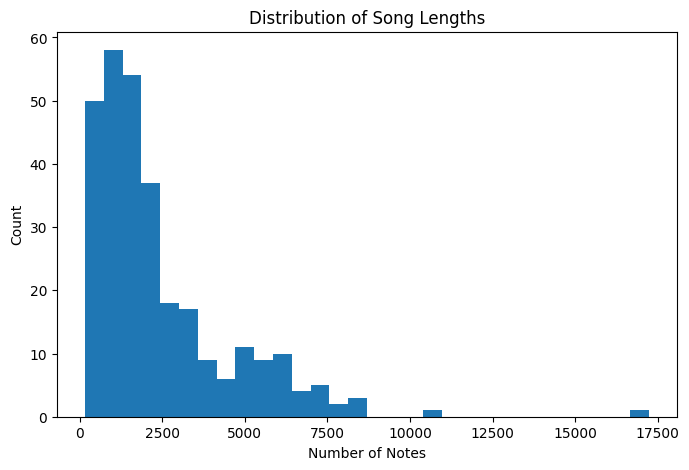

In [49]:

plt.figure(figsize=(8,5))

plt.hist(lengths, bins=30)

plt.xlabel("Number of Notes")

plt.ylabel("Count")

plt.title("Distribution of Song Lengths")

plt.show()

In [50]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 512

songs_pad = pad_sequences(
    songs,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    value=0
)

print(songs_pad.shape)

c:\python\Sina\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


(295, 512)


In [51]:
class MIDIDataset(Dataset):

    def __init__(self, data):

        self.data = torch.LongTensor(data)

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        return self.data[idx]

In [52]:
train_data, val_data = train_test_split(
    songs_pad,
    test_size=0.2,
    random_state=42
)

In [53]:

train_dataset = MIDIDataset(train_data)
val_dataset = MIDIDataset(val_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [54]:
class MusicVAE(nn.Module):
    
    def __init__(
        self,
        vocab_size=128,
        embed_dim=128,
        hidden_dim=256,
        latent_dim=64,
        num_layers=2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim
        )

        self.encoder = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc_mu = nn.Linear(
            hidden_dim,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            hidden_dim,
            latent_dim
        )

        self.fc_latent = nn.Linear(
            latent_dim,
            hidden_dim
        )

        self.decoder = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.output = nn.Linear(
            hidden_dim,
            vocab_size
        )
    def encode(self, x):
    
        x = self.embedding(x)

        _, h = self.encoder(x)

        h = h[-1]

        mu = self.fc_mu(h)

        logvar = self.fc_logvar(h)

        return mu, logvar
    def reparameterize(self, mu, logvar):
    
        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std
    def decode(self, z, seq_len):
    
        h = self.fc_latent(z)

        h = h.unsqueeze(0).repeat(2,1,1)

        inputs = torch.zeros(
            z.size(0),
            seq_len,
            dtype=torch.long,
            device=z.device
        )

        inputs = self.embedding(inputs)

        out, _ = self.decoder(
            inputs,
            h
        )

        out = self.output(out)

        return out
    def forward(self, x):
    
        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        out = self.decode(
            z,
            x.size(1)
        )

        return out, mu, logvar

In [55]:
model = MusicVAE()

x = next(iter(train_loader))

out, mu, logvar = model(x)

print(out.shape)
print(mu.shape)
print(logvar.shape)

torch.Size([16, 512, 128])
torch.Size([16, 64])
torch.Size([16, 64])


In [56]:
def music_vae_loss(outputs, targets, mu, logvar, beta=1.0):
    
    recon_loss = F.cross_entropy(
        outputs.reshape(-1, outputs.size(-1)),
        targets.reshape(-1),
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [57]:
def train_epoch_music(model,
                      loader,
                      optimizer,
                      device,
                      epoch,
                      total_epochs):

    model.train()

    running_loss = 0
    running_recon = 0
    running_kl = 0

    beta = beta_scheduler(epoch, total_epochs)

    for songs in train_loader:

        songs = songs.to(device)

        optimizer.zero_grad()

        outputs, mu, logvar = model(songs)

        loss, recon, kl = music_vae_loss(
            outputs,
            songs,
            mu,
            logvar,
            beta
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_recon += recon.item()
        running_kl += kl.item()

    return (
        running_loss/len(loader),
        running_recon/len(loader),
        running_kl/len(loader)
    )

In [58]:
@torch.no_grad()
def evaluate_music(model,
                   loader,
                   device,
                   epoch,
                   total_epochs):

    model.eval()

    running_loss = 0
    running_recon = 0
    running_kl = 0

    beta = beta_scheduler(epoch,total_epochs)

    for songs in loader:

        songs = songs.to(device)

        outputs, mu, logvar = model(songs)

        loss, recon, kl = music_vae_loss(
            outputs,
            songs,
            mu,
            logvar,
            beta
        )

        running_loss += loss.item()
        running_recon += recon.item()
        running_kl += kl.item()

    return (
        running_loss/len(loader),
        running_recon/len(loader),
        running_kl/len(loader)
    )

In [59]:
music_vae = MusicVAE().to(device)

optimizer = torch.optim.Adam(
    music_vae.parameters(),
    lr=1e-3
)

EPOCHS = 30

best_val = float("inf")

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    train_loss, train_rec, train_kl = train_epoch_music(
        music_vae,
        train_loader,
        optimizer,
        device,
        epoch,
        EPOCHS
    )

    val_loss, val_rec, val_kl = evaluate_music(
        music_vae,
        val_loader,
        device,
        epoch,
        EPOCHS
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | β={beta_scheduler(epoch,EPOCHS):.2f}"
        f" | Train={train_loss:.4f}"
        f" | Val={val_loss:.4f}"
    )

    if val_loss < best_val:

        best_val = val_loss

        torch.save(
            music_vae.state_dict(),
            "best_music_vae.pth"
        )

Epoch 1/30 | β=0.00 | Train=4.0428 | Val=3.7728
Epoch 2/30 | β=0.00 | Train=3.7395 | Val=3.7252
Epoch 3/30 | β=0.00 | Train=3.7410 | Val=3.7097
Epoch 4/30 | β=0.00 | Train=3.6681 | Val=3.6366
Epoch 5/30 | β=0.00 | Train=3.6045 | Val=3.5746
Epoch 6/30 | β=0.04 | Train=3.6296 | Val=3.5978
Epoch 7/30 | β=0.08 | Train=3.5712 | Val=3.5726
Epoch 8/30 | β=0.12 | Train=3.5301 | Val=3.5516
Epoch 9/30 | β=0.15 | Train=3.5060 | Val=3.5646
Epoch 10/30 | β=0.19 | Train=3.4931 | Val=3.5481
Epoch 11/30 | β=0.23 | Train=3.4616 | Val=3.5187
Epoch 12/30 | β=0.27 | Train=3.4351 | Val=3.5130
Epoch 13/30 | β=0.31 | Train=3.4471 | Val=3.5404
Epoch 14/30 | β=0.35 | Train=3.4563 | Val=3.5512
Epoch 15/30 | β=0.38 | Train=3.4409 | Val=3.5295
Epoch 16/30 | β=0.42 | Train=3.4364 | Val=3.4920
Epoch 17/30 | β=0.46 | Train=3.4179 | Val=3.4941
Epoch 18/30 | β=0.50 | Train=3.3977 | Val=3.4854
Epoch 19/30 | β=0.54 | Train=3.4262 | Val=3.4665
Epoch 20/30 | β=0.58 | Train=3.4024 | Val=3.4736
Epoch 21/30 | β=0.62 | Train=

In [60]:
music_vae.load_state_dict(
    torch.load(
        "best_music_vae.pth",
        map_location=device
    )
)

music_vae.eval()

z = torch.randn(
    1,
    64,
    device=device
)

with torch.no_grad():

    logits = music_vae.decode(
        z,
        seq_len=512
    )

notes = logits.argmax(-1).squeeze().cpu().numpy()

In [61]:
import pretty_midi

midi = pretty_midi.PrettyMIDI()

instrument = pretty_midi.Instrument(program=0)

start = 0

duration = 0.4

for pitch in notes:

    if pitch == 0:
        start += duration
        continue

    note = pretty_midi.Note(
        velocity=100,
        pitch=int(pitch),
        start=start,
        end=start+duration
    )

    instrument.notes.append(note)

    start += duration

midi.instruments.append(instrument)

midi.write("generated_music.mid")